# **Day-12 | Exam mark prediction using Linear Regression-multipleVariable**

### *Import Libraries*

In [18]:
import pandas as pd
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

### *Load Dataset from Local Directory*

In [19]:
from google.colab import files
uploaded = files.upload()

Saving data.csv to data (1).csv


### *Load Dataset*

In [20]:
dataset = pd.read_csv('data.csv')

### *Load Summarize*

In [21]:
print("Dataset Shape:", dataset.shape)
print(dataset.head(5))

Dataset Shape: (201, 4)
   hours  age  internet  marks
0   6.83   15         1  78.50
1   6.56   16         0  76.74
2    NaN   17         1  78.68
3   5.67   18         0  71.82
4   8.67   19         1  84.19


### *Finding & Removing NA values from our Features X*

In [22]:
dataset.columns[dataset.isna().any()]

Index(['hours'], dtype='object')

In [23]:
dataset.hours = dataset.hours.fillna(dataset.hours.mean())

### *Segregate Dataset into Input X & Output Y*

In [24]:
X = dataset.iloc[:, :-1].values
print(X.shape)
X

(201, 3)


array([[ 6.83      , 15.        ,  1.        ],
       [ 6.56      , 16.        ,  0.        ],
       [ 6.99061538, 17.        ,  1.        ],
       [ 5.67      , 18.        ,  0.        ],
       [ 8.67      , 19.        ,  1.        ],
       [ 7.55      , 20.        ,  0.        ],
       [ 6.67      , 15.        ,  0.        ],
       [ 8.99      , 16.        ,  0.        ],
       [ 6.99061538, 17.        ,  1.        ],
       [ 6.75      , 18.        ,  0.        ],
       [ 6.59      , 19.        ,  0.        ],
       [ 8.56      , 20.        ,  1.        ],
       [ 7.75      , 15.        ,  0.        ],
       [ 7.9       , 16.        ,  1.        ],
       [ 8.19      , 17.        ,  0.        ],
       [ 6.55      , 18.        ,  1.        ],
       [ 6.36      , 19.        ,  0.        ],
       [ 8.44      , 20.        ,  1.        ],
       [ 8.41      , 15.        ,  0.        ],
       [ 7.67      , 16.        ,  1.        ],
       [ 7.42      , 17.        ,  1.   

In [25]:
Y = dataset.iloc[:, -1].values
Y

array([78.5 , 76.74, 78.68, 71.82, 84.19, 81.18, 76.99, 85.46, 70.66,
       77.82, 75.37, 83.88, 79.5 , 80.76, 83.08, 76.03, 76.04, 85.11,
       82.5 , 80.58, 82.18, 83.36, 70.67, 75.02, 70.96, 83.33, 74.75,
       75.65, 74.15, 80.17, 82.27, 76.14, 71.1 , 84.35, 83.08, 76.76,
       81.24, 78.21, 73.08, 83.23, 70.27, 86.41, 71.1 , 82.84, 82.38,
       72.96, 77.46, 70.11, 72.38, 71.41, 72.22, 77.77, 84.44, 71.45,
       82.21, 85.48, 75.03, 86.65, 70.9 , 71.7 , 73.61, 79.41, 76.19,
       80.43, 85.78, 70.06, 81.25, 81.7 , 69.27, 82.79, 71.8 , 71.79,
       74.97, 78.61, 77.59, 72.33, 72.08, 77.33, 70.05, 73.34, 84.  ,
       82.93, 76.63, 75.36, 77.29, 72.87, 73.4 , 81.74, 71.85, 84.6 ,
       79.56, 82.1 , 72.08, 79.1 , 81.01, 76.48, 75.39, 68.57, 83.64,
       82.3 , 75.18, 82.03, 82.99, 79.26, 77.55, 77.07, 72.1 , 73.25,
       74.25, 70.58, 81.08, 75.04, 76.38, 80.86, 78.42, 74.44, 70.34,
       85.04, 73.61, 75.55, 76.2 , 82.69, 76.83, 79.53, 83.57, 85.95,
       76.02, 77.65,

# *train/test split*

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, Y, test_size=0.25, random_state=0
)

### *Training Dataset using Linear Regression*

In [27]:
model = LinearRegression()
model.fit(X,Y)

LinearRegression()

# *prediction*

In [28]:
y_pred = model.predict(X_test)

### *Predicted Price for Land sq.Feet of custom values*

In [29]:
a=[[9.2,20,0]]
PredictedmodelResult = model.predict(a)
print(PredictedmodelResult)

[86.27252618]


# *Evaluate model*

In [30]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Mean Absolute Error (MAE): {mae:.2f}")
print(f"Mean Squared Error (MSE): {mse:.2f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f}")
print(f"R² Score: {r2:.2f}")

Mean Absolute Error (MAE): 0.96
Mean Squared Error (MSE): 2.12
Root Mean Squared Error (RMSE): 1.46
R² Score: 0.90


# 9️⃣ Predict Custom Study Hours
## *Example: predict marks for 6 hours of study*

In [31]:
hours_age_internet = np.array([[6, 20, 0]]) # Assuming 6 hours, 20 years old, no internet
predicted_marks = model.predict(hours_age_internet)
print(f"Predicted Exam Marks for 6 hours (age 20, no internet): {predicted_marks[0]:.2f}")

Predicted Exam Marks for 6 hours (age 20, no internet): 74.24


# *visualization*

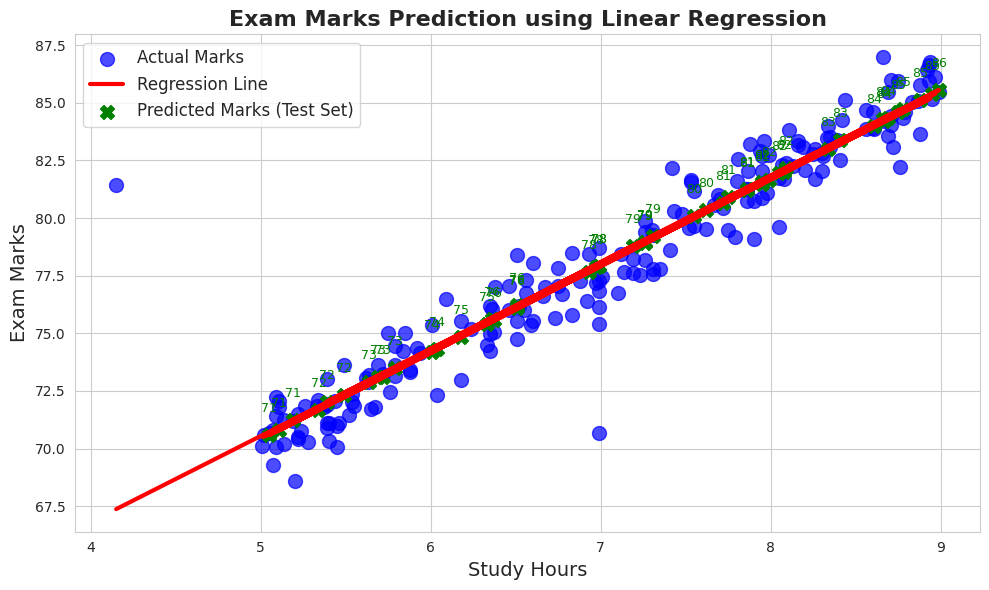

In [32]:
# 1️⃣ Import Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Set Seaborn style for industry-level look
sns.set_style("whitegrid")
plt.figure(figsize=(10,6))

# 2️⃣ Scatter Plot of Actual Data
plt.scatter(X[:, 0], Y, color='blue', label='Actual Marks', s=100, alpha=0.7)

# 3️⃣ Regression Line
plt.plot(X[:, 0], model.predict(X), color='red', linewidth=3, label='Regression Line')

# 4️⃣ Predicted Points (Optional: Highlight test set predictions)
plt.scatter(X_test[:, 0], y_pred, color='green', label='Predicted Marks (Test Set)', s=100, marker='X')

# 5️⃣ Annotate Predictions (for test set)
for i, j in zip(X_test[:, 0], y_pred):
    plt.text(i, j+1, f"{j:.0f}", fontsize=9, color='green', ha='center')

# 6️⃣ Labels & Title
plt.xlabel("Study Hours", fontsize=14)
plt.ylabel("Exam Marks", fontsize=14)
plt.title("Exam Marks Prediction using Linear Regression", fontsize=16, fontweight='bold')
plt.legend(fontsize=12)
plt.tight_layout()

# 7️⃣ Show Plot
plt.show()